# 04 - Train/Val EDA and Multicollinearity

## Goal
- run feature EDA only on train+val,
- analyze feature covariance and multicollinearity,
- select a cleaner feature set (constant/correlation/VIF),
- apply selected features to train/val/test,
- save artifacts for the next notebook.


In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from stylin import InfoDisplayStyler

In [ ]:
styler = InfoDisplayStyler()

In [3]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'
CLEAN_PATH = '../../data/clean/'
LABELED_PATH = '../../data/labeled/'
PROCESSED_PATH = '../../data/processed/'

TRAIN_FEATURES_FILE = PROCESSED_PATH + 'train_features.csv'
VAL_FEATURES_FILE = PROCESSED_PATH + 'val_features.csv'
TEST_FEATURES_FILE = PROCESSED_PATH + 'test_features.csv'

assert os.path.exists(TRAIN_FEATURES_FILE), 'Missing train_features.csv. Run notebook 03 first.'
assert os.path.exists(VAL_FEATURES_FILE), 'Missing val_features.csv. Run notebook 03 first.'
assert os.path.exists(TEST_FEATURES_FILE), 'Missing test_features.csv. Run notebook 03 first.'

train_df = pd.read_csv(TRAIN_FEATURES_FILE)
val_df = pd.read_csv(VAL_FEATURES_FILE)
test_df = pd.read_csv(TEST_FEATURES_FILE)

for df in [train_df, val_df, test_df]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')

styler.show_meta(train_df)
styler.style_me(train_df.head(5), title='Train feature preview')


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,future_return,target,return_1,return_2,return_3,return_6,return_12,return_24,log_return_1,log_return_6,log_return_24,close_open_pct,high_low_pct,upper_shadow,lower_shadow,body_size,rolling_close_mean_6,rolling_return_std_6,rolling_close_min_6,rolling_close_max_6,rolling_return_skew_6,rolling_return_kurt_6,rolling_close_mean_12,rolling_return_std_12,rolling_close_min_12,rolling_close_max_12,rolling_return_skew_12,rolling_return_kurt_12,rolling_close_mean_24,rolling_return_std_24,rolling_close_min_24,rolling_close_max_24,rolling_return_skew_24,rolling_return_kurt_24,rolling_close_mean_48,rolling_return_std_48,rolling_close_min_48,rolling_close_max_48,rolling_return_skew_48,rolling_return_kurt_48,roc_6,momentum_6,sma_6,ema_6,dist_sma_6,dist_ema_6,roc_12,momentum_12,sma_12,ema_12,dist_sma_12,dist_ema_12,roc_24,momentum_24,sma_24,ema_24,dist_sma_24,dist_ema_24,rsi_14,macd,macd_signal,macd_hist,atr_14,bb_width,bb_position,volume_return,volume_mean_24,volume_std_24,volume_zscore_24,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,return_1_lag_1,return_1_lag_2,return_1_lag_3,return_6_lag_1,return_6_lag_2,return_6_lag_3,rsi_14_lag_1,rsi_14_lag_2,rsi_14_lag_3,macd_hist_lag_1,macd_hist_lag_2,macd_hist_lag_3,volume_zscore_24_lag_1,volume_zscore_24_lag_2,volume_zscore_24_lag_3
0,2021-01-03 00:00:00+00:00,774.440000,778.860000,770.590000,775.810000,34582.741650,26814528.488316,28322,17514.734930,13581009.350799,0.031129,2,0.001614,0.004688,0.008921,-0.005385,0.031141,0.077664,0.001613,-0.005399,0.074795,0.001769,0.010660,0.003931,0.004963,0.001766,772.141667,0.018041,756.550000,784.790000,-1.948287,4.513416,772.815000,0.015751,756.550000,784.790000,-1.259378,2.632827,752.766250,0.013078,725.410000,784.790000,-0.643982,3.065160,743.730000,0.010508,719.900000,784.790000,-0.136671,3.567542,-0.005385,-4.200000,772.141667,772.738655,0.004728,0.003959,0.031141,23.430000,772.815000,767.850954,0.003860,0.010259,0.077664,55.910000,752.766250,758.272455,0.029703,0.022605,61.211387,10.765491,9.842602,0.922889,15.939286,0.110961,0.719223,-0.096854,55875.464283,43008.063166,-0.495087,0.000000,1.000000,-0.781831,0.623490,1,0.003069,0.004214,0.016390,-0.005495,-0.012469,0.000677,60.680589,59.709908,58.406418,1.204475,1.540458,2.053545,-0.421914,-0.774749,0.337353
1,2021-01-03 01:00:00+00:00,775.840000,779.000000,772.350000,776.970000,27914.487110,21663976.812176,18434,13437.424570,10429518.919297,0.029358,2,0.001495,0.003111,0.006190,-0.009964,0.008044,0.065247,0.001494,-0.010014,0.063207,0.001456,0.008559,0.002613,0.004492,0.001454,770.838333,0.017784,756.550000,776.970000,-1.855123,4.341083,773.331667,0.014183,756.550000,784.790000,-1.630953,3.772491,754.749167,0.012907,725.410000,784.790000,-0.568431,3.282952,744.327708,0.010162,719.900000,784.790000,-0.162931,4.256054,-0.009964,-7.820000,770.838333,773.947611,0.007892,0.003890,0.008044,6.200000,773.331667,769.253884,0.004683,0.009931,0.065247,47.590000,754.749167,759.768259,0.028599,0.022140,61.727730,10.695492,10.013180,0.682312,16.133571,0.108214,0.710874,-0.192820,55455.840413,43238.714742,-0.636960,0.258819,0.965926,-0.781831,0.623490,1,0.001614,0.003069,0.004214,-0.005385,-0.005495,-0.012469,61.211387,60.680589,59.709908,0.922889,1.204475,1.540458,-0.495087,-0.421914,-0.774749
2,2021-01-03 02:00:00+00:00,776.980000,781.590000,775.480000,778.940000,23590.906850,18364302.756458,16621,11896.808840,9261412.824715,0.049837,2,0.002535,0.004034,0.005655,0.029595,0.023655,0.067860,0.002532,0.029165,0.065657,0.002523,0.007844,0.003402,0.001926,0.002516,774.570000,0.005724,768.950000,778.940000,2.285897,5.357582,774.831667,0.013530,756.550000,784.790000,-2.109688,6.289927,756.811667,0.012895,725.410000,784.790000,-0.595568,3.330025,745.054375,0.010120,719.900000,784.790000,-0.211759,4.391384,0.029595,22.390000,774.570000,775.374008,0.005610,0.004578,0.023655,18.000000,774.831667,77

## 1. Input checks and train+val setup


In [4]:
required_cols = ['timestamp', 'target', 'future_return']
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = [c for c in required_cols if c not in part.columns]
    assert not missing, f'{name}: missing required columns {missing}'
    assert part['timestamp'].notna().all(), f'{name}: invalid timestamp values'

train_df = train_df.sort_values('timestamp').reset_index(drop=True)
val_df = val_df.sort_values('timestamp').reset_index(drop=True)
test_df = test_df.sort_values('timestamp').reset_index(drop=True)

train_val_df = pd.concat([train_df, val_df], axis=0).sort_values('timestamp').reset_index(drop=True)

meta_cols = ['timestamp', 'target', 'future_return']
feature_cols = [c for c in train_val_df.columns if c not in meta_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_val_df[c])]

input_report = pd.DataFrame({
    'split': ['train', 'val', 'test', 'train_val'],
    'rows': [len(train_df), len(val_df), len(test_df), len(train_val_df)],
    'feature_count': [len(feature_cols)] * 4,
    'min_ts': [train_df['timestamp'].min(), val_df['timestamp'].min(), test_df['timestamp'].min(), train_val_df['timestamp'].min()],
    'max_ts': [train_df['timestamp'].max(), val_df['timestamp'].max(), test_df['timestamp'].max(), train_val_df['timestamp'].max()],
})
styler.style_me(input_report, title='Input setup report')


,split,rows,feature_count,min_ts,max_ts
0,train,32326,96,2021-01-03 00:00:00+00:00,2024-09-11 13:00:00+00:00
1,val,6937,96,2024-09-11 14:00:00+00:00,2025-06-27 14:00:00+00:00
2,test,6939,96,2025-06-27 15:00:00+00:00,2026-04-12 17:00:00+00:00
3,train_val,39263,96,2021-01-03 00:00:00+00:00,2025-06-27 14:00:00+00:00


## 2. Histograms and pairplot (train+val only)


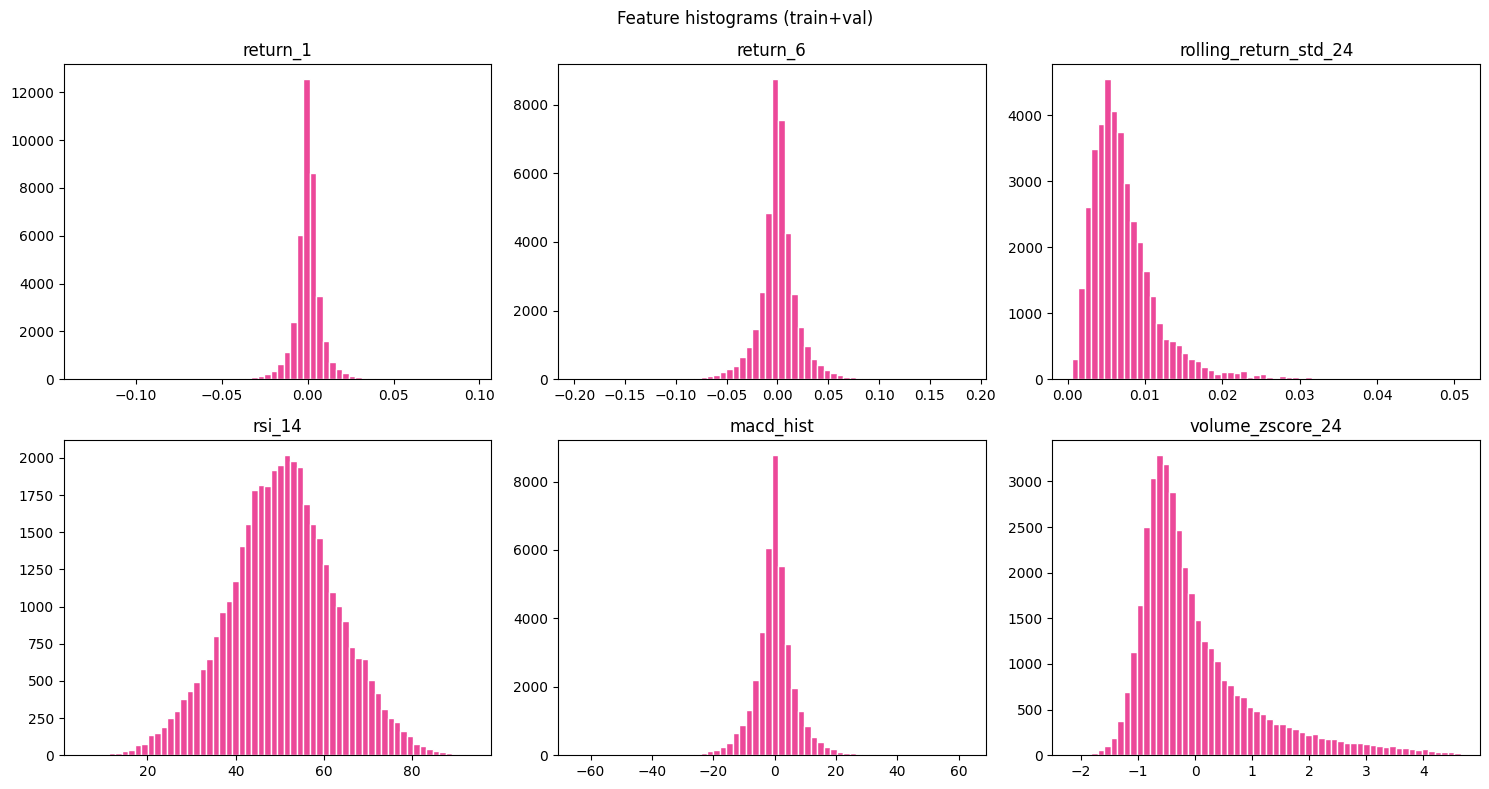

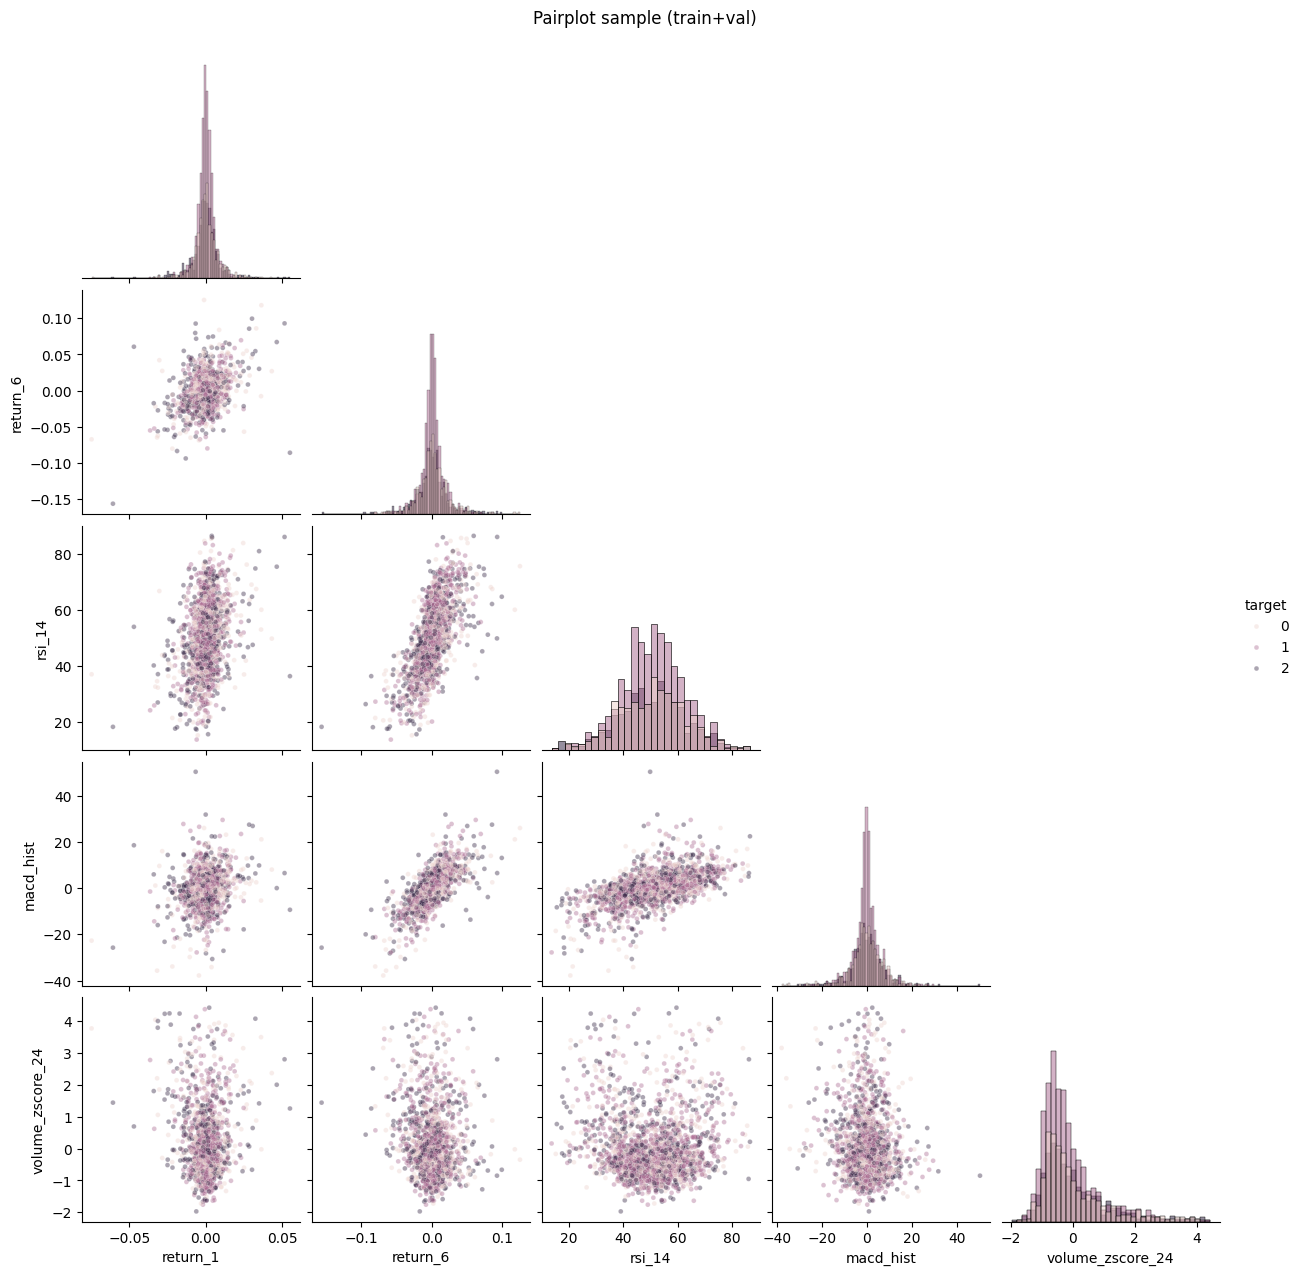

In [5]:
eda_candidates = [
    'return_1',
    'return_6',
    'rolling_return_std_24',
    'rsi_14',
    'macd_hist',
    'volume_zscore_24',
]
eda_features = [c for c in eda_candidates if c in feature_cols]

if len(eda_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(eda_features):
        axes[i].hist(train_val_df[col], bins=60, color='#ec4899', edgecolor='white')
        axes[i].set_title(col)
    for j in range(len(eda_features), len(axes)):
        axes[j].axis('off')
    plt.suptitle('Feature histograms (train+val)')
    plt.tight_layout()
    plt.show()

pairplot_cols = [c for c in ['return_1', 'return_6', 'rsi_14', 'macd_hist', 'volume_zscore_24', 'target'] if c in train_val_df.columns]
if len(pairplot_cols) >= 3:
    sample_n = min(2000, len(train_val_df))
    pairplot_df = train_val_df[pairplot_cols].sample(sample_n, random_state=42)
    sns.pairplot(pairplot_df, hue='target', diag_kind='hist', corner=True, plot_kws={'alpha': 0.4, 's': 12})
    plt.suptitle('Pairplot sample (train+val)', y=1.02)
    plt.show()


## 3. Feature covariance and high-correlation filter


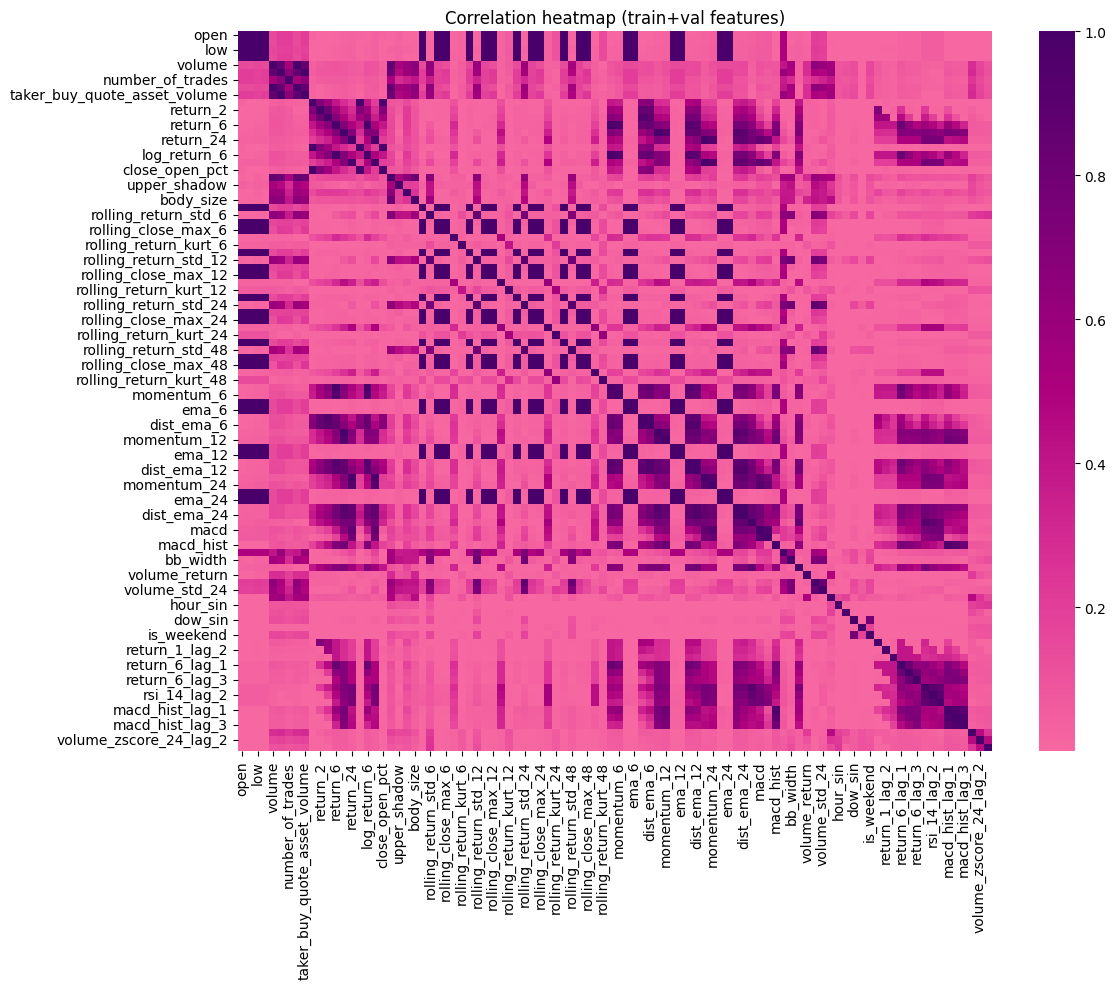

,stage,feature_count
0,initial_features,96
1,after_constant_drop,96
2,after_corr_drop,59


,dropped_constant


,dropped_corr
0,high
1,low
2,close
3,taker_buy_base_asset_volume
4,taker_buy_quote_asset_volume
5,log_return_1
6,log_return_6
7,log_return_24
8,close_open_pct
9,rolling_close_mean_6


In [6]:
def drop_constant_features(df: pd.DataFrame, min_unique: int = 2):
    to_drop = [c for c in df.columns if df[c].nunique(dropna=False) < min_unique]
    return df.drop(columns=to_drop), to_drop


def drop_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.95):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop, corr

X_train_val = train_val_df[feature_cols].copy()
X_train_val = X_train_val.replace([np.inf, -np.inf], np.nan)
X_train_val = X_train_val.dropna().copy()

X_no_const, dropped_constant = drop_constant_features(X_train_val)
X_no_corr, dropped_corr, corr_matrix = drop_highly_correlated_features(X_no_const, threshold=0.95)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='RdPu', center=0)
plt.title('Correlation heatmap (train+val features)')
plt.tight_layout()
plt.show()

filter_report = pd.DataFrame({
    'stage': ['initial_features', 'after_constant_drop', 'after_corr_drop'],
    'feature_count': [len(X_train_val.columns), len(X_no_const.columns), len(X_no_corr.columns)],
})
styler.style_me(filter_report, title='Feature count after constant/correlation filters')
styler.style_me(pd.DataFrame({'dropped_constant': dropped_constant}), title='Dropped constant features')
styler.style_me(pd.DataFrame({'dropped_corr': dropped_corr}), title='Dropped high-corr features')


## 4. VIF analysis (iterative)


In [7]:
def reduce_vif_features(
    df: pd.DataFrame,
    vif_threshold: float = 10.0,
    max_iter: int = 100,
    sample_n: int | None = 15000,
):
    work = df.copy()
    work = work.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).dropna()

    if sample_n is not None and len(work) > sample_n:
        work_eval = work.sample(sample_n, random_state=42)
    else:
        work_eval = work.copy()

    if work_eval.shape[1] < 2:
        return list(work.columns), [], pd.DataFrame(columns=['feature', 'vif'])

    cols = list(work_eval.columns)
    dropped = []

    for _ in range(max_iter):
        vif_values = []
        for i, col in enumerate(cols):
            try:
                v = variance_inflation_factor(work_eval[cols].values, i)
            except Exception:
                v = np.inf
            vif_values.append(float(v))

        vif_df = pd.DataFrame({'feature': cols, 'vif': vif_values}).sort_values('vif', ascending=False)
        max_vif = float(vif_df['vif'].iloc[0])

        if max_vif <= vif_threshold or len(cols) < 2:
            return cols, dropped, vif_df

        drop_col = str(vif_df['feature'].iloc[0])
        cols.remove(drop_col)
        dropped.append(drop_col)

    final_vif = pd.DataFrame({'feature': cols, 'vif': [np.nan] * len(cols)})
    return cols, dropped, final_vif

kept_after_vif, dropped_vif, vif_table = reduce_vif_features(
    X_no_corr,
    vif_threshold=10.0,
    max_iter=100,
    sample_n=15000,
)

styler.style_me(vif_table.head(30), title='Top VIF values (after iterative reduction)')
styler.style_me(pd.DataFrame({'dropped_vif': dropped_vif}), title='Dropped VIF features')


,feature,vif
1,quote_asset_volume,9.571680
8,rolling_return_std_6,8.709788
4,return_12,7.407583
21,bb_position,7.403507
20,bb_width,7.373171
23,volume_std_24,7.257533
33,return_6_lag_1,6.887832
0,open,6.820138
17,momentum_6,6.291887
19,macd_hist,5.741295


,dropped_vif
0,upper_shadow
1,return_2
2,return_3
3,rsi_14_lag_1
4,rsi_14_lag_2
5,rsi_14
6,dist_sma_12
7,dist_sma_6
8,dist_sma_24
9,rolling_return_std_24


## 5. Feature-target relation (train+val)


,feature,mutual_info
1,quote_asset_volume,0.046206
8,rolling_return_std_6,0.043782
2,number_of_trades,0.041060
23,volume_std_24,0.037399
20,bb_width,0.036469
0,open,0.031818
7,body_size,0.022439
18,macd,0.022126
5,return_24,0.019261
6,lower_shadow,0.017242


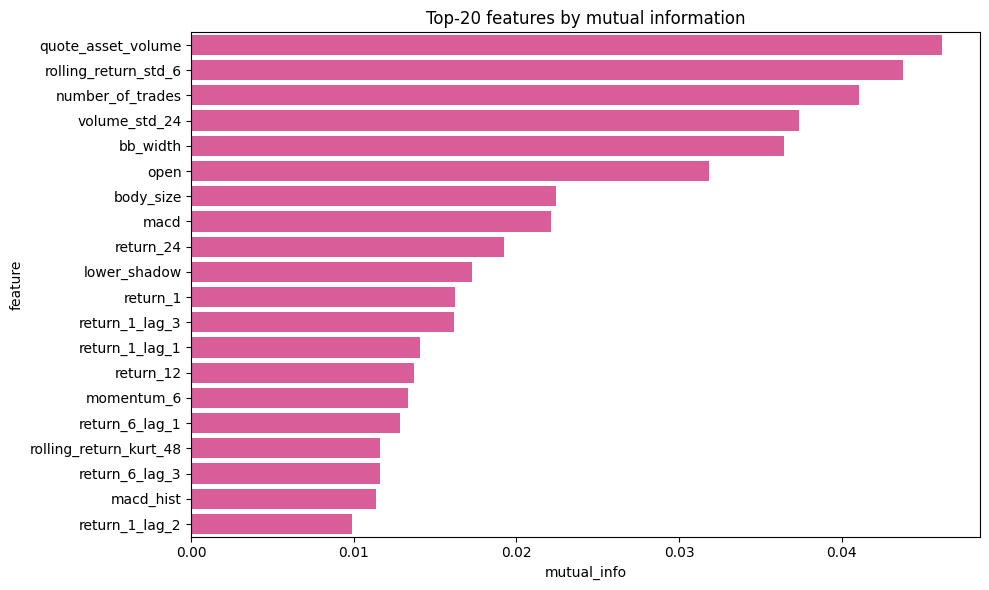

In [8]:
X_mi = X_no_corr[kept_after_vif].copy()
y_mi = train_val_df.loc[X_mi.index, 'target'].astype(int)

mi_values = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'mutual_info': mi_values}).sort_values('mutual_info', ascending=False)

styler.style_me(mi_df.head(30), title='Top features by mutual information (train+val)')

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(20), x='mutual_info', y='feature', color='#ec4899')
plt.title('Top-20 features by mutual information')
plt.tight_layout()
plt.show()


## 6. Final selected feature set and apply to train/val/test


In [9]:
selected_features = kept_after_vif.copy()

final_drop_set = set(dropped_constant) | set(dropped_corr) | set(dropped_vif)
final_drop_list = sorted(final_drop_set)

train_selected = train_df[['timestamp', 'target', 'future_return'] + selected_features].copy()
val_selected = val_df[['timestamp', 'target', 'future_return'] + selected_features].copy()
test_selected = test_df[['timestamp', 'target', 'future_return'] + selected_features].copy()

selection_summary = pd.DataFrame({
    'metric': [
        'initial_feature_count',
        'dropped_constant_count',
        'dropped_corr_count',
        'dropped_vif_count',
        'final_selected_count',
    ],
    'value': [
        len(feature_cols),
        len(dropped_constant),
        len(dropped_corr),
        len(dropped_vif),
        len(selected_features),
    ],
})
styler.style_me(selection_summary, title='Feature selection summary')


,metric,value
0,initial_feature_count,96
1,dropped_constant_count,0
2,dropped_corr_count,37
3,dropped_vif_count,21
4,final_selected_count,38


## 7. Save artifacts


In [10]:
TRAIN_SELECTED_OUT = PROCESSED_PATH + 'train_selected.csv'
VAL_SELECTED_OUT = PROCESSED_PATH + 'val_selected.csv'
TEST_SELECTED_OUT = PROCESSED_PATH + 'test_selected.csv'
SELECTED_FEATURES_OUT = PROCESSED_PATH + 'selected_feature_columns.csv'
SELECTION_REPORT_OUT = PROCESSED_PATH + 'feature_selection_report.csv'
DROP_LIST_OUT = PROCESSED_PATH + 'dropped_features_report.csv'
MI_REPORT_OUT = PROCESSED_PATH + 'feature_target_mi.csv'
VIF_REPORT_OUT = PROCESSED_PATH + 'vif_table.csv'

train_selected.to_csv(TRAIN_SELECTED_OUT, index=False)
val_selected.to_csv(VAL_SELECTED_OUT, index=False)
test_selected.to_csv(TEST_SELECTED_OUT, index=False)

pd.DataFrame({'feature_column': selected_features}).to_csv(SELECTED_FEATURES_OUT, index=False)
selection_summary.to_csv(SELECTION_REPORT_OUT, index=False)
pd.DataFrame({'dropped_feature': final_drop_list}).to_csv(DROP_LIST_OUT, index=False)
mi_df.to_csv(MI_REPORT_OUT, index=False)
vif_table.to_csv(VIF_REPORT_OUT, index=False)

styler.show_line(TRAIN_SELECTED_OUT, title='Saved train_selected')
styler.show_line(VAL_SELECTED_OUT, title='Saved val_selected')
styler.show_line(TEST_SELECTED_OUT, title='Saved test_selected')
styler.show_line(SELECTED_FEATURES_OUT, title='Saved selected features list')
styler.show_line(SELECTION_REPORT_OUT, title='Saved selection summary')


## 8. Final conclusions (fill after run)
- How many features were removed by each criterion?
- Is the final feature set stable and interpretable?
- Are train/val/test selected datasets ready for scaling and dataloaders in notebook 05?


Wnioski końcowe (Notebook 04)
Analiza EDA i selekcja cech została wykonana poprawnie metodologicznie na zbiorze train+val (bez używania testu do podejmowania decyzji), co ogranicza ryzyko leakage.
Początkowo model miał 96 cech wejściowych; po filtracji otrzymano 38 cech finalnych:

usunięte cechy stałe: 0
usunięte przez wysoką korelację (|corr| > 0.95): 37
usunięte przez VIF (VIF > 10): 21
Łącznie usunięto 58 cech, a więc redukcja była istotna i poprawiła jakość przestrzeni cech pod kątem multikolinearności.
Końcowa tabela VIF potwierdza stabilność zestawu: max VIF ≈ 9.57 (poniżej progu 10), mediana VIF ≈ 2.71.

Po selekcji zbiory mają:

train_selected: 32 328 x 41
val_selected: 6 937 x 41
test_selected: 6 939 x 41
(41 kolumn = timestamp, target, future_return + 38 cech modelowych).
Rozkłady klas pozostały spójne z wcześniejszym etapem, więc selekcja cech nie zaburzyła struktury targetu.

Najbardziej informacyjne cechy względem targetu (MI) to m.in. quote_asset_volume, rolling_return_std_6, number_of_trades, volume_std_24, bb_width, co potwierdza, że sygnał predykcyjny pochodzi zarówno z